In [1]:
import sys
sys.path.append("../../src")

import numpy as np
from numba import njit
from scipy.stats import ortho_group
from tqdm import tqdm
import matplotlib.pyplot as plt

from python_utils.visualization_utils import display_matrix, plot_bss_comparison, subplot_1D_signals
from bss.bss_utils import generate_correlated_copula_sources, addWGN
from bss.PredictiveDecorrBSS import PredictiveDecorrBSS

# Generate Sources and Mix Them (10 by 5 case)

In [2]:
# np.random.seed(400)
seed = np.random.randint(5000000)
np.random.seed(seed)
print("seed is ", seed)
N = 40000
NumberofSources = 5
NumberofMixtures = NumberofSources + 5

S = generate_correlated_copula_sources(rho=0.0, df=4,
                                       n_sources=NumberofSources, 
                                       size_sources=N, 
                                       decreasing_correlation=False)
S = 2 * S - 1
print("The following is the correlation matrix of sources")
display_matrix(np.corrcoef(S))

# # Generate Mxr random mixing from i.i.d N(0,1)
A = np.random.randn(NumberofMixtures, NumberofSources) # Random Gaussian mixing matrix
# A = ortho_group.rvs(dim=NumberofSources) # Random orthogonal mixing matrix
X_noNoise = np.dot(A, S)


SNR = 30
X = addWGN(X_noNoise, SNR)

SNRinp = 10 * np.log10(
    np.sum(np.mean(X_noNoise ** 2, axis=1))
    / np.sum(np.mean((X_noNoise - X)**2, axis=1))
)
print("The following is the mixture matrix A")
display_matrix(A)
print("Input SNR is : {}".format(SNRinp))
S.var(1), X.var(1)

seed is  245743
The following is the correlation matrix of sources


<IPython.core.display.Math object>

The following is the mixture matrix A


<IPython.core.display.Math object>

Input SNR is : 29.97353983648115


(array([0.33518944, 0.3338428 , 0.33250034, 0.33545328, 0.33113688]),
 array([1.20450513, 3.20570741, 1.70532336, 2.50291813, 0.81399944,
        3.82836222, 2.81151022, 4.20150877, 0.52617262, 2.7891164 ]))

# Hyperparameters

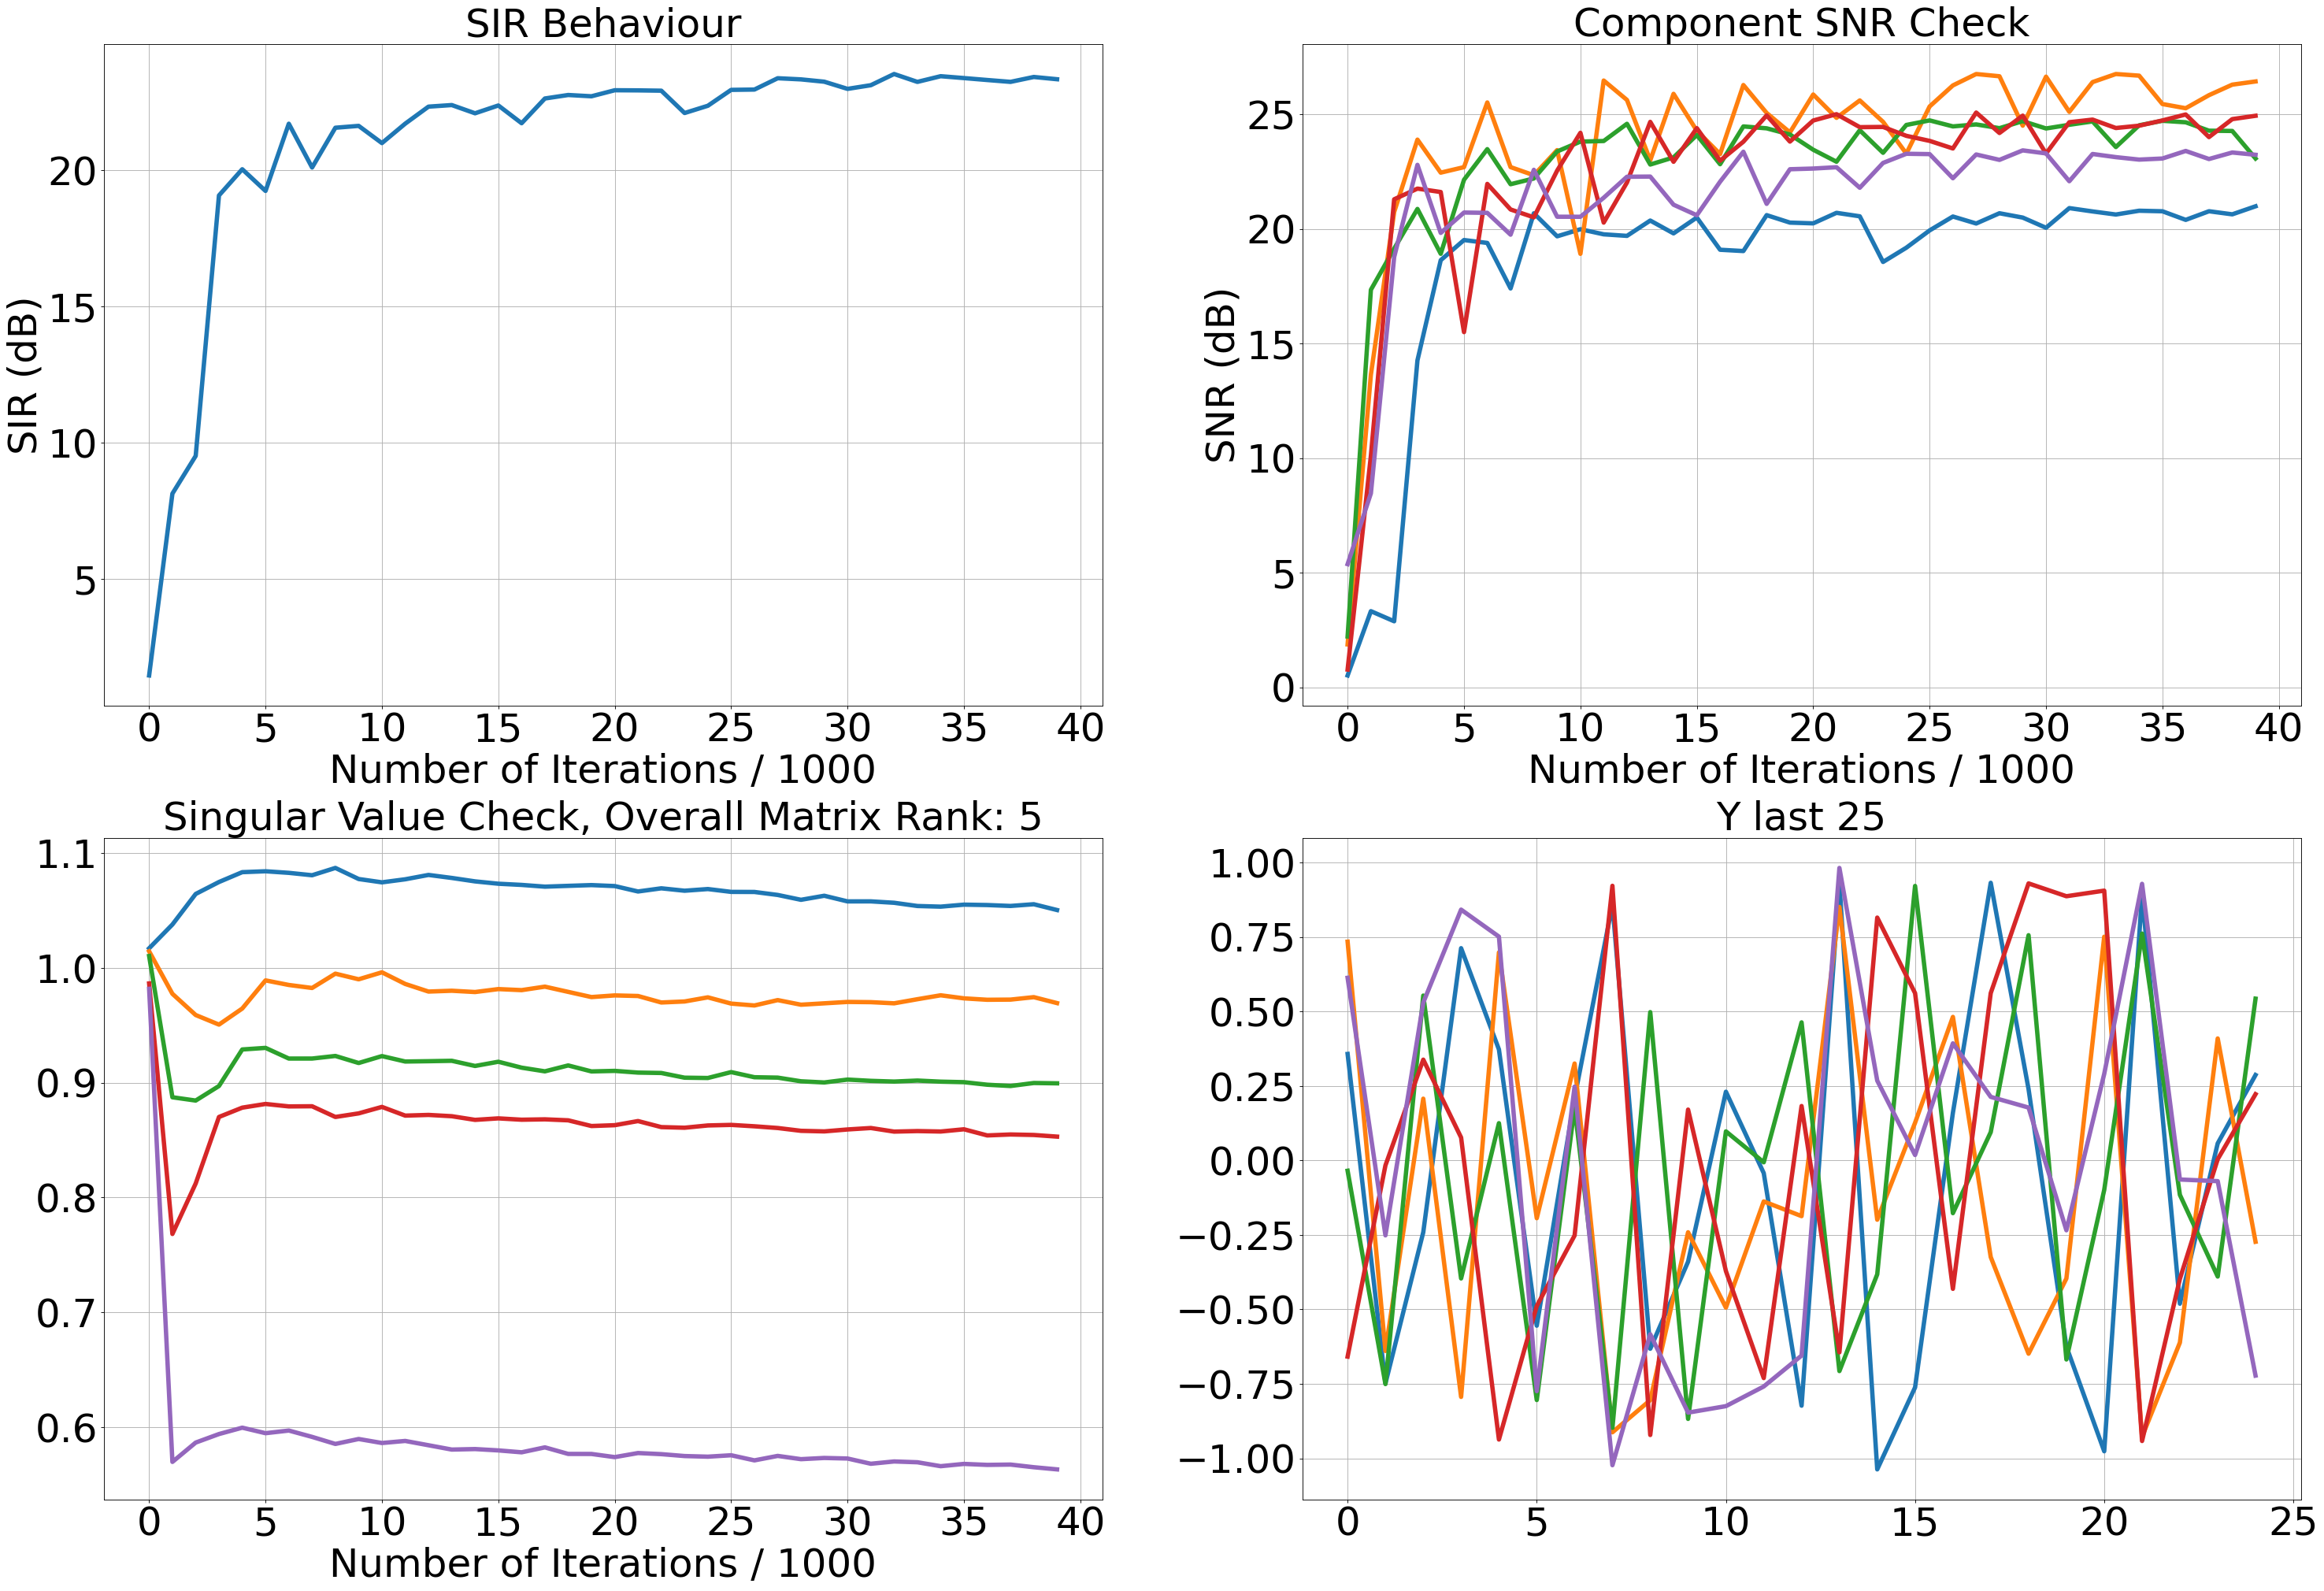

100%|██████████| 40000/40000 [00:42<00:00, 938.19it/s] 


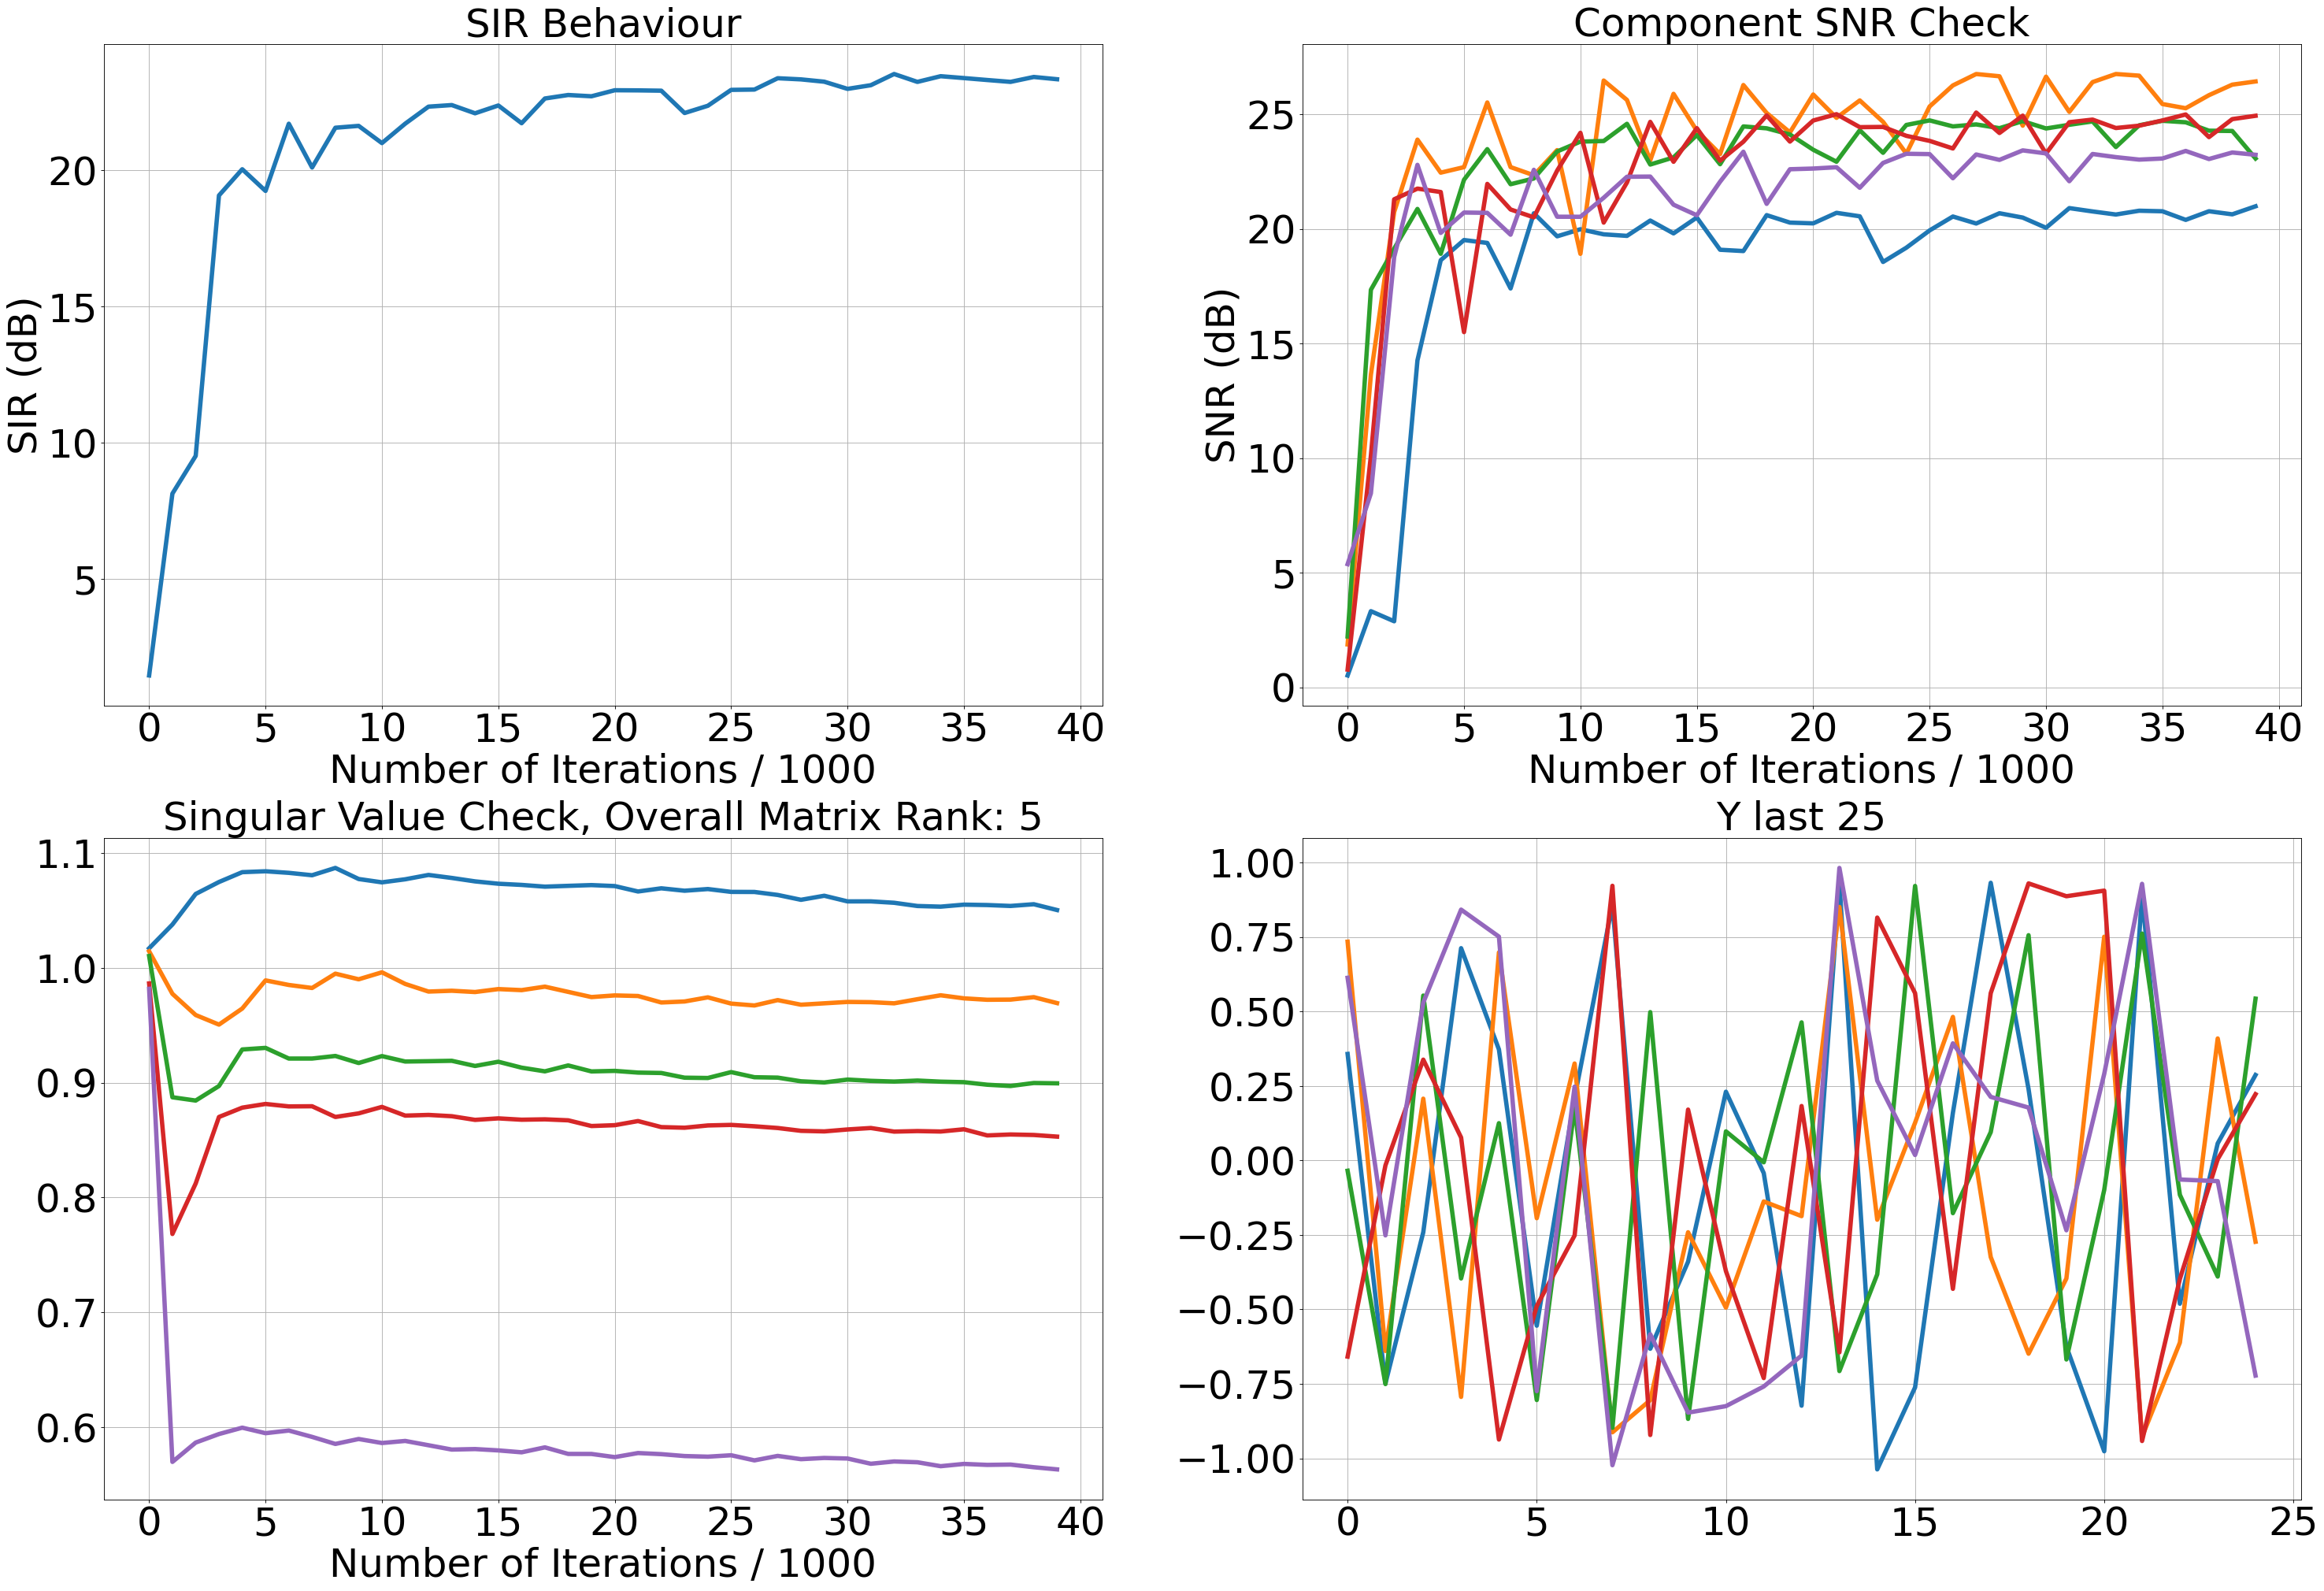

In [3]:
hyperparam_dict = {
                "n_sources" :  NumberofSources,
                "presumed_domain" : "antisparse",
                ### Optimization parameters
                "lambda_lateral" : 0.99,
                "gamma_predictive" : 250,
                ### Learning rates 
                "lr_W" : 5 * 1e-2,
                "neural_lr_start" : 0.5,
                "neural_lr_stop" : 1e-6,
                "neural_dynamics_iterations" : 250,
                "neural_OUTPUT_COMP_TOL" : 1e-7,
                ### Learning rate rules and decay parameters
                "lr_W_rule" : "divide_by_index",
                "lr_W_decay_divider" : 5000,
                "neural_lr_rule" : "divide_by_loop_index",
                "neural_lr_decay_divider" : 200,
                ### Initial values for weights if provided, if not they will be initialized in the fit function 
                "W" : None,
                "C_y" : None,
                "mu_y" : None, 
                ### Ground truth source vectors. This part is only for debugging.
                "Sgt" : S,
                "debug_iteration_point" : 1000,
                "plot_debug_during_training" : True,
                "save_C_y_per_debug" : True
}
model = PredictiveDecorrBSS(**hyperparam_dict)
C_y_sq = np.random.randn(NumberofSources, NumberofSources) / 5 + np.sqrt(0.2)*np.eye(NumberofSources)
model.C_y = C_y_sq @ C_y_sq.T
model.fit(X)

In [4]:
display_matrix(model.C_y)

<IPython.core.display.Math object>

In [5]:
display_matrix(model.mu_y.reshape(1, -1))

<IPython.core.display.Math object>

In [6]:
display_matrix(model.W)

<IPython.core.display.Math object>

In [7]:
Y_ = model.predict(X)
Y_ = model.signed_and_permutation_corrected_sources(S, Y_) # Find sign and permutation ambiguity
coef_ = ((Y_ * S).sum(axis=1) / (Y_ * Y_).sum(axis=1)).reshape(-1, 1) # Find if the extracted signals need some amplification! The networks learned weight may need amplification due to lateral connections during the neural dynamics!
Y_ = coef_ * Y_

print("Signal-to-Interference-and-Noise-Ratio (SINR): {}".format(model.ComputeSINR(Y_, S)))
print("Component Signal-to-Noise-Ratio (SNR) Values : {}\n".format(model.ComputeSNR(S, Y_)))

Signal-to-Interference-and-Noise-Ratio (SINR): 23.292498296089885
Component Signal-to-Noise-Ratio (SNR) Values : [20.87035951 25.84389935 24.2874558  23.63892131 23.50654603]



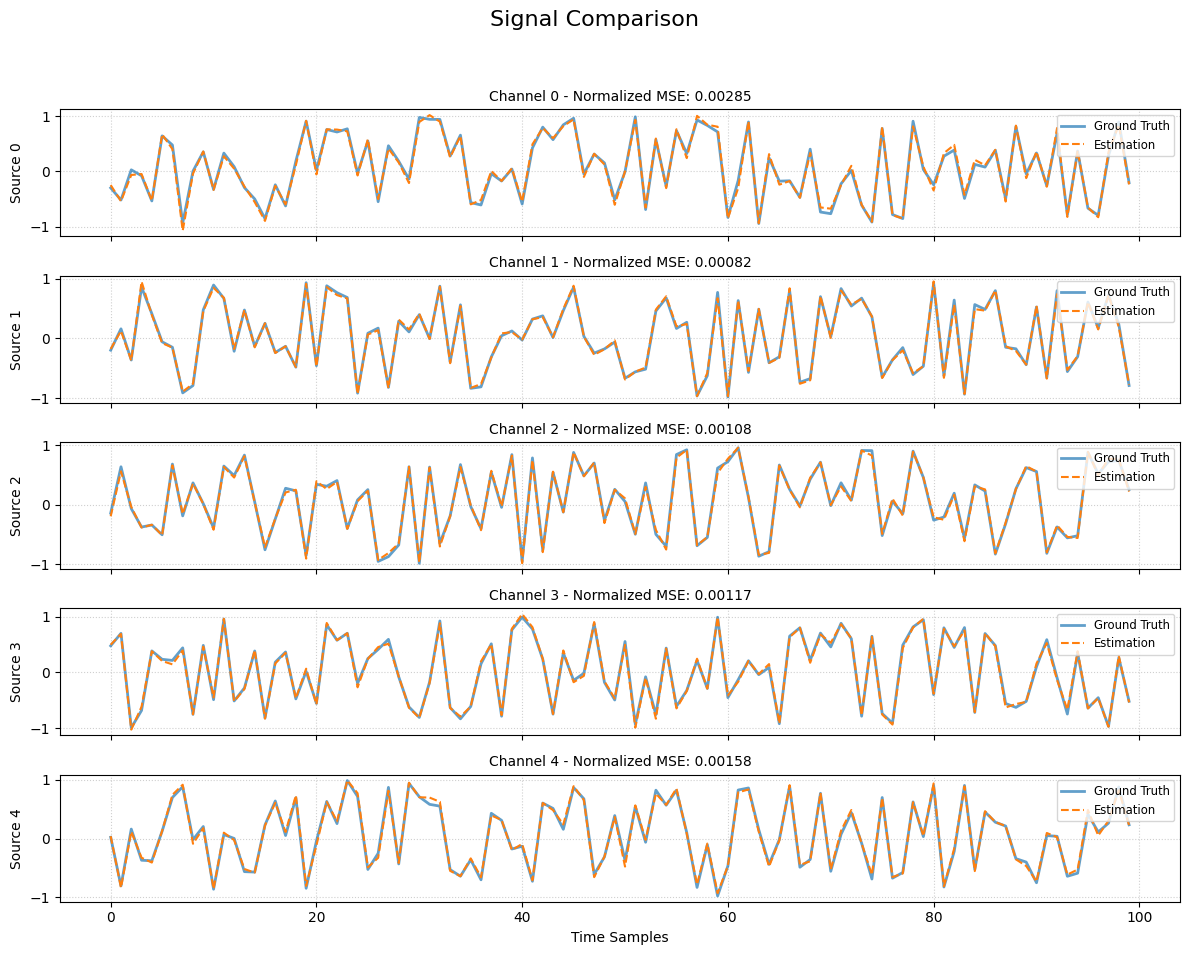

In [8]:
plot_bss_comparison(S[:, 0:100], Y_[:, 0:100])

In [9]:
def evaluate_taylor_surrogate(C_y):
    """
    Evaluates the exact log-determinant, its 2nd-order Taylor surrogate, 
    and the theoretical error upper bound for a given covariance matrix.

    Args:
        C_y (np.ndarray): A symmetric, positive-definite covariance matrix of shape (n, n).

    Returns:
        tuple: (original_energy, approximate_energy, error_upper_bound)
    """
    # 1. Original Energy Term (Exact Log-Determinant)
    sign, logabsdet = np.linalg.slogdet(C_y)
    original_energy = sign * logabsdet

    # 2. Approximate Energy Term (2nd-Order Taylor Surrogate)
    D_y_vec = np.diag(C_y)
    O_y = C_y - np.diag(D_y_vec)
    
    # Calculate D^{-1} O using broadcasting (faster and more numerically stable than np.linalg.inv)
    trace_inside_term = (1.0 / D_y_vec.reshape(-1, 1)) * O_y
    
    approximate_energy = np.sum(np.log(D_y_vec)) - 0.5 * np.linalg.trace(trace_inside_term @ trace_inside_term)

    # 3. Theoretical Error Upper Bound
    O_frob_sq = np.linalg.norm(O_y, ord='fro')**2
    O_spectral = np.linalg.norm(O_y, ord=2)
    
    # Minimum eigenvalue of C_y (using eigvalsh since C_y is a symmetric matrix)
    lambda_min_C = np.min(np.linalg.eigvalsh(C_y))
    
    # Calculate the analytical bound
    error_upper_bound = (1.0 / 3.0) * (O_frob_sq * O_spectral) / (lambda_min_C**3)

    return original_energy, approximate_energy, error_upper_bound

In [10]:
original_energy, approximate_energy, error_upper_bound = evaluate_taylor_surrogate(model.C_y_list[0])

# Print everything to compare
actual_error = np.abs(original_energy - approximate_energy)

print(f"Actual Error:      {actual_error}")
print(f"Theoretical Bound: {error_upper_bound}")
print(f"Is Bound Valid?:   {error_upper_bound >= actual_error}")

Actual Error:      1.8363490537867246
Theoretical Bound: 354614.8222384053
Is Bound Valid?:   True


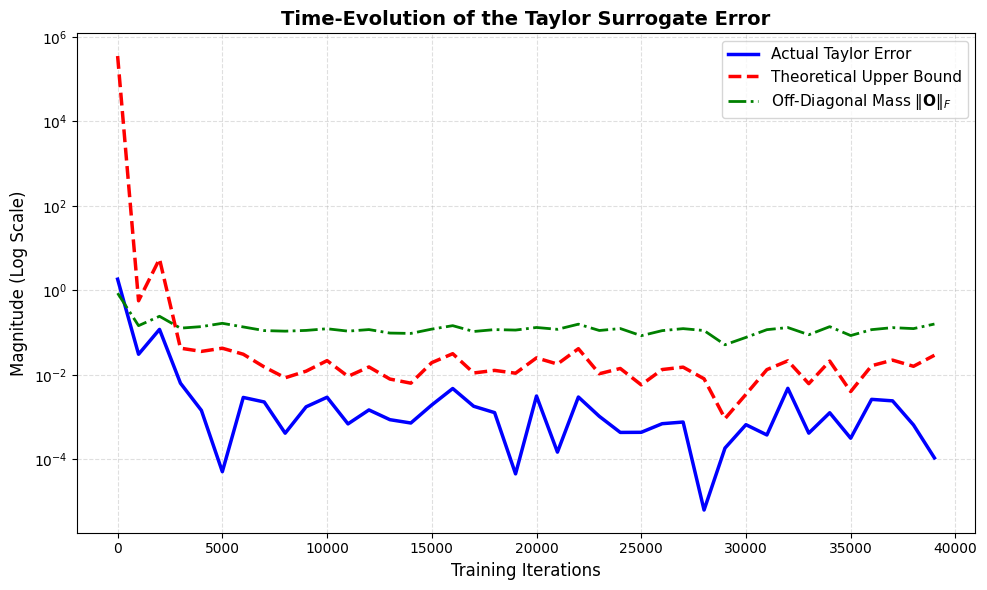

In [11]:
def evaluate_taylor_surrogate_batch(model_C_y_list):
    """
    Iterates over a sequence of covariance matrices to compute the Taylor 
    surrogate metrics for each matrix.

    Args:
        model_C_y_list (list): A list of symmetric, positive-definite covariance 
                               matrices (np.ndarray) recorded during training.

    Returns:
        tuple: A tuple containing three lists:
            - actual_errors (list): The absolute difference between the exact 
              log-determinant and the 2nd-order Taylor approximation.
            - theoretical_bounds (list): The analytically derived upper bound 
              for the approximation error.
            - off_diagonal_norms (list): The Frobenius norm of the off-diagonal 
              matrix O_y for each time step.
            (Note: A small epsilon of 1e-16 is added to errors and bounds to 
            prevent log(0) issues during plotting).
    """
    actual_errors = []
    theoretical_bounds = []
    off_diagonal_norms = []
    
    for C_y in model_C_y_list:
        # 1. Get metrics from our previously defined function
        orig_energy, approx_energy, bound = evaluate_taylor_surrogate(C_y)
        actual_error = np.abs(orig_energy - approx_energy)
        
        # 2. Calculate the Frobenius norm of the off-diagonal matrix O_y
        D_y_vec = np.diag(C_y)
        O_y = C_y - np.diag(D_y_vec)
        O_frob_norm = np.linalg.norm(O_y, ord='fro')
        
        # 3. Store the results
        # We add a tiny epsilon (1e-16) to avoid log(0) warnings in the plot if they hit exactly 0
        actual_errors.append(actual_error + 1e-16)
        theoretical_bounds.append(bound + 1e-16)
        off_diagonal_norms.append(O_frob_norm)
        
    return actual_errors, theoretical_bounds, off_diagonal_norms


def plot_taylor_surrogate_evolution(model_C_y_list, record_interval=1):
    """
    Evaluates and plots the time-evolution of the Taylor surrogate error, 
    the theoretical upper bound, and the off-diagonal mass over a sequence 
    of training iterations.
    
    Args:
        model_C_y_list (list): A list of C_y matrices recorded during training.
        record_interval (int, optional): The number of training iterations 
                                         between each recorded matrix. Used 
                                         to correctly scale the x-axis. 
                                         Defaults to 1.
                                         
    Returns:
        None (Displays a matplotlib figure).
    """
    actual_errors, theoretical_bounds, off_diagonal_norms = evaluate_taylor_surrogate_batch(model_C_y_list)
    
    # Generate the x-axis iteration numbers
    iterations = np.arange(len(model_C_y_list)) * record_interval
    
    # --- Plotting ---
    plt.figure(figsize=(10, 6))
    
    # Plot on a logarithmic y-axis
    plt.semilogy(iterations, actual_errors, 
                 label='Actual Taylor Error', color='blue', linewidth=2.5)
    
    plt.semilogy(iterations, theoretical_bounds, 
                 label='Theoretical Upper Bound', color='red', linestyle='--', linewidth=2.5)
                 
    plt.semilogy(iterations, off_diagonal_norms, 
                 label=r'Off-Diagonal Mass $\|\mathbf{O}\|_F$', color='green', linestyle='-.', linewidth=2)
    
    # Formatting the plot for publication
    plt.title('Time-Evolution of the Taylor Surrogate Error', fontsize=14, fontweight='bold')
    plt.xlabel('Training Iterations', fontsize=12)
    plt.ylabel('Magnitude (Log Scale)', fontsize=12)
    plt.grid(True, which="both", linestyle='--', alpha=0.4)
    plt.legend(fontsize=11, loc='upper right')
    
    plt.tight_layout()
    plt.show()

plot_taylor_surrogate_evolution(model.C_y_list, record_interval=1000)

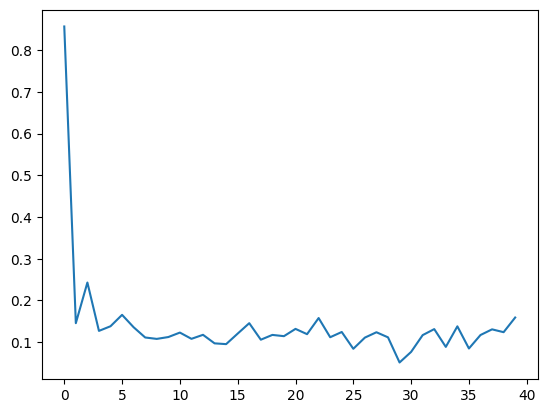

In [12]:
actual_errors, theoretical_bounds, off_diagonal_norms = evaluate_taylor_surrogate_batch(model.C_y_list)
plt.plot(off_diagonal_norms)

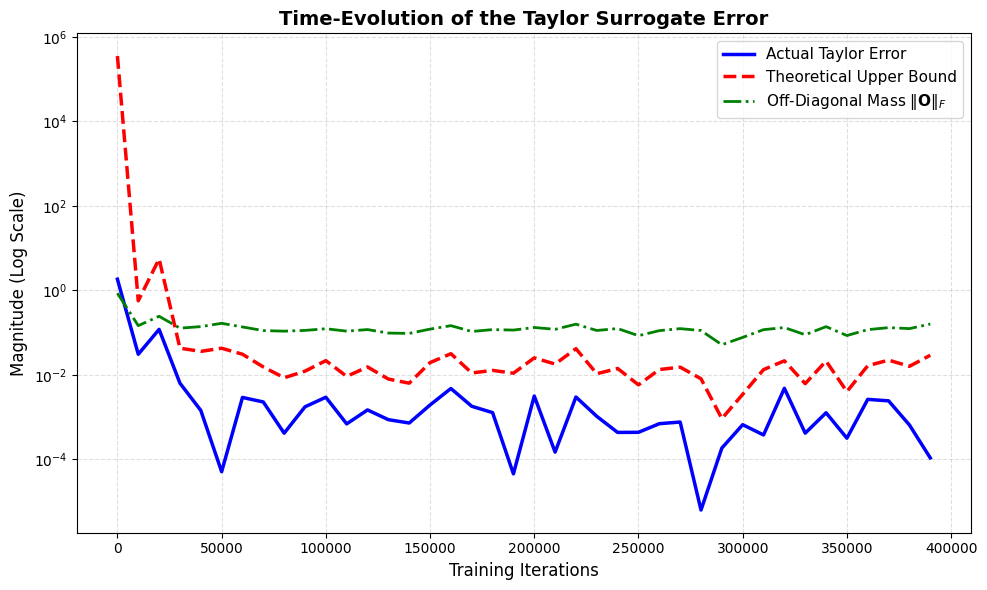

In [13]:
def plot_taylor_surrogate_evolution(model_C_y_list, record_interval=1):
    """
    Evaluates and plots the Taylor surrogate error and theoretical bound 
    over a sequence of covariance matrices (training iterations).
    
    Args:
        model_C_y_list (list): A list of C_y matrices recorded during training.
        record_interval (int): The number of iterations between each recorded C_y 
                               (used for scaling the x-axis).
    """
    # actual_errors = []
    # theoretical_bounds = []
    # off_diagonal_norms = []
    
    # for C_y in model_C_y_list:
    #     # 1. Get metrics from our previously defined function
    #     orig_energy, approx_energy, bound = evaluate_taylor_surrogate(C_y)
    #     actual_error = np.abs(orig_energy - approx_energy)
        
    #     # 2. Calculate the Frobenius norm of the off-diagonal matrix O_y
    #     D_y_vec = np.diag(C_y)
    #     O_y = C_y - np.diag(D_y_vec)
    #     O_frob_norm = np.linalg.norm(O_y, ord='fro')
        
    #     # 3. Store the results
    #     # We add a tiny epsilon (1e-16) to avoid log(0) warnings in the plot if they hit exactly 0
    #     actual_errors.append(actual_error + 1e-16)
    #     theoretical_bounds.append(bound + 1e-16)
    #     off_diagonal_norms.append(O_frob_norm)

    actual_errors, theoretical_bounds, off_diagonal_norms = evaluate_taylor_surrogate_batch(model_C_y_list)
    # Generate the x-axis iteration numbers
    iterations = np.arange(len(model_C_y_list)) * record_interval
    
    # --- Plotting ---
    plt.figure(figsize=(10, 6))
    
    # Plot on a logarithmic y-axis
    plt.semilogy(iterations, actual_errors, 
                 label='Actual Taylor Error', color='blue', linewidth=2.5)
    
    plt.semilogy(iterations, theoretical_bounds, 
                 label='Theoretical Upper Bound', color='red', linestyle='--', linewidth=2.5)
                 
    plt.semilogy(iterations, off_diagonal_norms, 
                 label=r'Off-Diagonal Mass $\|\mathbf{O}\|_F$', color='green', linestyle='-.', linewidth=2)
    
    # Formatting the plot for publication
    plt.title('Time-Evolution of the Taylor Surrogate Error', fontsize=14, fontweight='bold')
    plt.xlabel('Training Iterations', fontsize=12)
    plt.ylabel('Magnitude (Log Scale)', fontsize=12)
    plt.grid(True, which="both", linestyle='--', alpha=0.4)
    plt.legend(fontsize=11, loc='upper right')
    
    plt.tight_layout()
    plt.show()

# --- How to use it ---
# Assuming you saved your matrices in a list during your training loop:
plot_taylor_surrogate_evolution(model.C_y_list, record_interval=10000)

In [14]:
C_y = model.C_y
(sign, logabsdet) = np.linalg.slogdet(C_y)
logdet_C_y = sign * logabsdet
logdet_C_y # Original energy term

np.float64(-4.924005094605045)

In [15]:
D_y = np.diag(C_y)
O_y = C_y - np.diag(D_y)
trace_inside_term = (1 / D_y.reshape(-1, 1)) * O_y 
approximate_log_det_C_y = np.log(D_y).sum() - np.linalg.trace(trace_inside_term @ trace_inside_term)
approximate_log_det_C_y

np.float64(-4.980559323987949)

In [16]:
C_y = model.C_y

# --- 1. Original Energy Term ---
(sign, logabsdet) = np.linalg.slogdet(C_y)
logdet_C_y = sign * logabsdet

# --- 2. Approximate Energy Term ---
# Extract diagonal as 1D array and off-diagonal matrix
D_y_vec = np.diag(C_y) 
O_y = C_y - np.diag(D_y_vec)

# Calculate D^{-1} O
trace_inside_term = (1 / D_y_vec.reshape(-1, 1)) * O_y  

# Fixed: Added the missing 0.5 multiplier for the second-order term!
approximate_log_det_C_y = np.sum(np.log(D_y_vec)) - 0.5 * np.linalg.trace(trace_inside_term @ trace_inside_term)

# --- 3. Error Upper Bound ---
# Frobenius norm squared of O_y
O_frob_sq = np.linalg.norm(O_y, ord='fro')**2

# Spectral norm (L2 norm) of O_y
O_spectral = np.linalg.norm(O_y, ord=2)

# Minimum eigenvalue of C_y 
# (Using eigvalsh since C_y is a symmetric matrix, which is numerically safer)
lambda_min_C = np.min(np.linalg.eigvalsh(C_y))

# Calculate the theoretical bound
error_upper_bound = (1.0 / 3.0) * (O_frob_sq * O_spectral) / (lambda_min_C**3)

# Print everything to compare
actual_error = np.abs(logdet_C_y - approximate_log_det_C_y)

print(f"Actual Error:      {actual_error}")
print(f"Theoretical Bound: {error_upper_bound}")
print(f"Is Bound Valid?:   {error_upper_bound >= actual_error}")

Actual Error:      0.0006493062648349479
Theoretical Bound: 0.014963277356324705
Is Bound Valid?:   True


In [17]:
np.linalg.eig(C_y)

EigResult(eigenvalues=array([0.46396256, 0.42549692, 0.30955537, 0.35799845, 0.33230196]), eigenvectors=array([[-0.63344574, -0.04634259, -0.66983504, -0.37122091, -0.10057297],
       [-0.15070885, -0.73305072,  0.3942689 , -0.44315357,  0.29680032],
       [-0.58094444,  0.37774654,  0.2960107 ,  0.24472433,  0.61016291],
       [-0.4467376 , -0.36720967,  0.20361759,  0.58467896, -0.53129367],
       [-0.19738902,  0.42773078,  0.51651775, -0.51387787, -0.49721515]]))

In [18]:
trace_inside_term = (1 / D_y.reshape(-1, 1)) * O_y 
np.log(D_y).sum() - np.linalg.trace(trace_inside_term @ trace_inside_term)

np.float64(-4.980559323987949)

In [19]:
np.linalg.pinv(np.diag(D_y)) @ O_y - (1 / D_y.reshape(-1, 1)) * O_y 

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

In [20]:
((1 / D_y.reshape(-1, 1)) * O_y )

array([[ 0.        ,  0.06858171,  0.12938808,  0.09604466,  0.07232408],
       [ 0.06712531,  0.        , -0.05097292,  0.06582557, -0.0622539 ],
       [ 0.12576317, -0.05061984,  0.        ,  0.06044531,  0.0601833 ],
       [ 0.09596371,  0.06719709,  0.06213513,  0.        , -0.03467351],
       [ 0.0771024 , -0.06780685,  0.06600879, -0.0369955 ,  0.        ]])